<a href="https://colab.research.google.com/github/Reeva-17/Customer-Churn-Prediction/blob/main/notebooks/05_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Reeva-17/Customer-Churn-Prediction.git

Cloning into 'Customer-Churn-Prediction'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 72 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 798.65 KiB | 2.89 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [3]:
%cd Customer-Churn-Prediction

/content/Customer-Churn-Prediction


In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

In [5]:
# Load Processed Dataset
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")

y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

In [6]:
# Verify Dataset
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5625, 30)
Testing Features  : (1407, 30)
Training Labels   : (5625,)
Testing Labels    : (1407,)


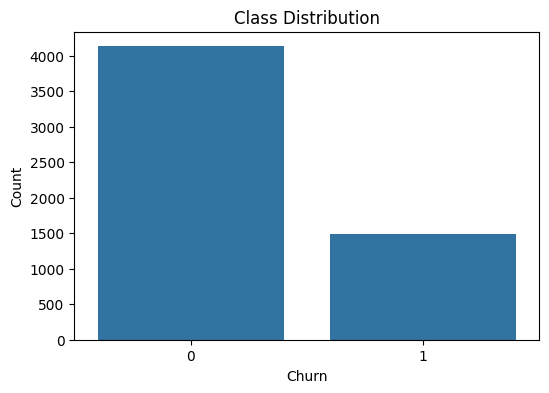

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [7]:
 # Explore Target Variable Distribution
 plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

print(y_train.value_counts(normalize=True))

In [8]:
# Build Baseline Decision Tree Model
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [9]:
#Train the Baseline Model
dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [10]:
# Make Predictions
y_pred = dt.predict(X_test)

In [11]:
# Evaluate Baseline Model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy : ",accuracy)

precision = precision_score(y_test, y_pred)

print("Precision : ",precision)

recall = recall_score(y_test, y_pred)

print("Recall : ",recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score : ",f1)


roc_auc = roc_auc_score(
    y_test,
    dt.predict_proba(X_test)[:,1]
)

print(f"ROC-AUC Score : {roc_auc:.4f}")

Accuracy :  0.7313432835820896
Precision :  0.4946236559139785
Recall :  0.4919786096256685
F1 Score :  0.4932975871313673
ROC-AUC Score : 0.6555


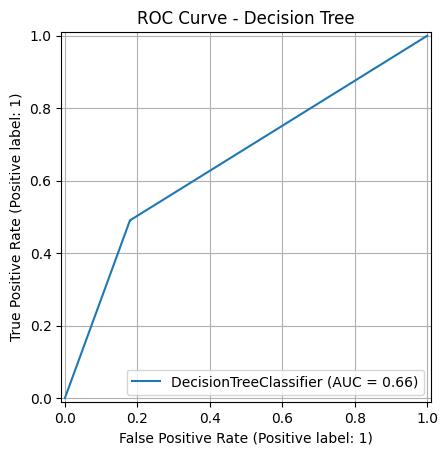

In [12]:
#ROC curve
RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")
plt.grid(True)
plt.show()

In [13]:
# Classification Report
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1407
   macro avg       0.66      0.65      0.66      1407
weighted avg       0.73      0.73      0.73      1407



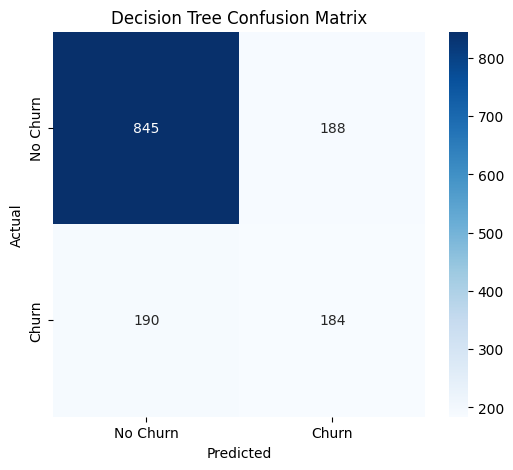

In [14]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [15]:
#Cross Validation
cv_scores = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross Validation F1 Scores")

print(cv_scores)

print()

print("Mean F1 Score :", cv_scores.mean())

Cross Validation F1 Scores
[0.4957265  0.50680272 0.51077944 0.49174917 0.49305556]

Mean F1 Score : 0.4996226766881097


In [16]:
 #Hyperparameter Tuning
param_grid = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "class_weight":[None,"balanced"]
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [17]:
# Best Hyperparameters
print("Best Parameters")

print(grid.best_params_)

print()

print("Best Cross Validation F1 Score")

print(grid.best_score_)

Best Parameters
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best Cross Validation F1 Score
0.6141021900024775


In [18]:
# Train the Optimized Decision Tree
best_dt = grid.best_estimator_

best_dt.fit(X_train,y_train)

best_pred = best_dt.predict(X_test)

In [19]:
#Evaluate the Tuned Model
best_accuracy = accuracy_score(y_test,best_pred)

best_precision = precision_score(y_test,best_pred)

best_recall = recall_score(y_test,best_pred)

best_f1 = f1_score(y_test,best_pred)

best_roc = roc_auc_score(
    y_test,
    best_dt.predict_proba(X_test)[:,1]
)

print("ROC-AUC :", best_roc)
print("Tuned Decision Tree Performance")
print("Accuracy : ",best_accuracy)
print("Precision: ",best_precision)
print("Recall   : ",best_recall)
print("F1 Score : ",best_f1)

ROC-AUC : 0.8212503429603821
Tuned Decision Tree Performance
Accuracy :  0.7256574271499645
Precision:  0.49032258064516127
Recall   :  0.8128342245989305
F1 Score :  0.6116700201207244


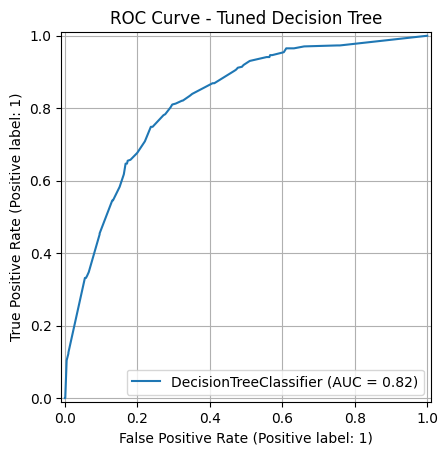

In [20]:
# ROC curve of Tuned Model
RocCurveDisplay.from_estimator(
    best_dt,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned Decision Tree")

plt.grid(True)

plt.show()

In [21]:
#Classification Report of Tuned Model
print("Classification Report")


print(classification_report(
    y_test,
    best_pred
))

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



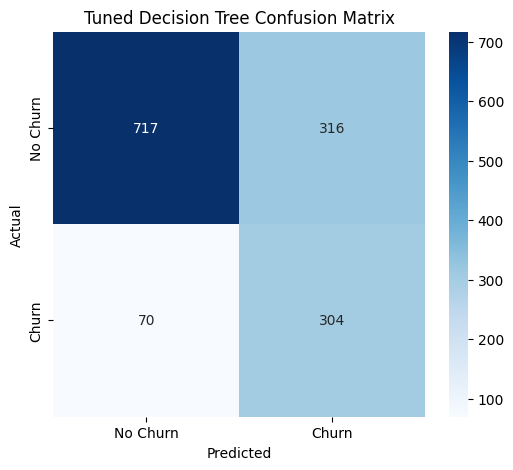

In [22]:
#Classification Report of Tuned Model
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Tuned Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
#Feature Importance
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_dt.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
25,Contract_Two year,0.334776
24,Contract_One year,0.222297
1,tenure,0.109761
10,InternetService_Fiber optic,0.085654
3,TotalCharges,0.057393
2,MonthlyCharges,0.056866
23,StreamingMovies_Yes,0.032575
28,PaymentMethod_Electronic check,0.030200
11,InternetService_No,0.015002
13,OnlineSecurity_Yes,0.011317


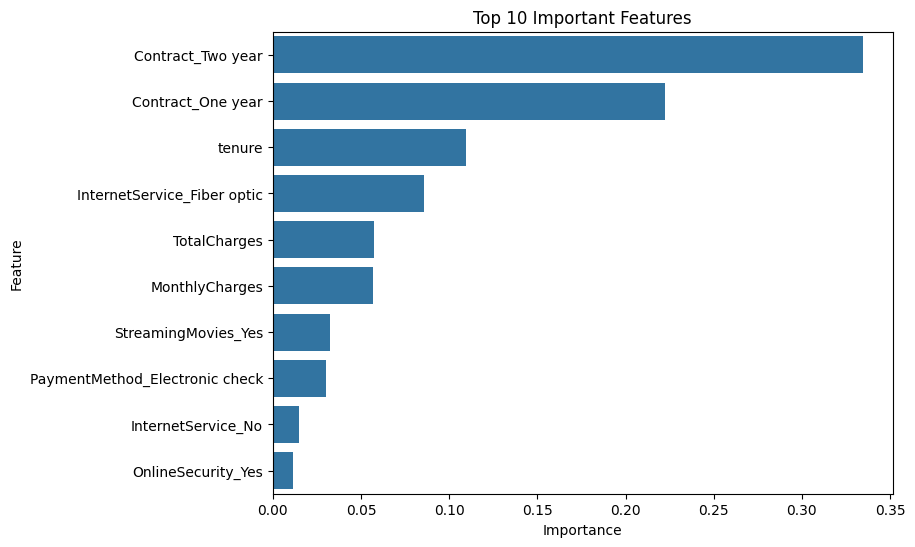

In [24]:
#Visualize Feature Importance

plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

In [26]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_dt,
    "models/decision_tree.pkl"
)
print("Decision Tree model saved successfully!")

Decision Tree model saved successfully!


In [27]:
results = pd.DataFrame({
    "Model":["Decision Tree"],
    "Accuracy":[best_accuracy],
    "Precision":[best_precision],
    "Recall":[best_recall],
    "F1 Score":[best_f1],
    "ROC-AUC":[best_roc]
})

os.makedirs("reports", exist_ok=True)

results.to_csv(
    "reports/decision_tree_results.csv",
    index=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.725657,0.490323,0.812834,0.61167,0.82125
